# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting"'):
    os.chdir('..')


In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from core.variables import *
from core.dgp import SingleSegmentTreatmentSelection as SingleSegment
import core.treatment_selection_single_segment as ts

# DGP

In [5]:
dgp = SingleSegment(
    te_arr = np.array([0.1, 0.2]), noise_std=1, response_type='continuous',
)
treatment_arr, outcome_arr = dgp.sample(sample_size=100, seed=0)

# Demand Model

In [6]:
emp_te_arr = ts.estimate_te(treatment_arr, outcome_arr)

for te_true, te_est in zip(dgp.te_arr, emp_te_arr):
    print(f"True TE: {te_true}, Estimated TE: {te_est:.4f}")

True TE: 0.1, Estimated TE: 0.1258
True TE: 0.2, Estimated TE: 0.2865


# Optimization

In [7]:
plugin_decision, plugin_val_est = ts.optimize(te_arr=emp_te_arr)
true_plugin_val = ts.obj_func(targ_decision=plugin_decision, te_arr=dgp.te_arr)

print(f'Plugin Decision: {plugin_decision}')
print(f'Estimated Targeting Value: {plugin_val_est:.2f}')
print(f'True Targeting Value: {true_plugin_val:.2f}')

print()
print(f"Winner's curse (measured in MPE): {100 * (plugin_val_est - true_plugin_val)/true_plugin_val:.2f}%")

Plugin Decision: 1
Estimated Targeting Value: 0.29
True Targeting Value: 0.20

Winner's curse (measured in MPE): 43.27%


## Shape of the Value function

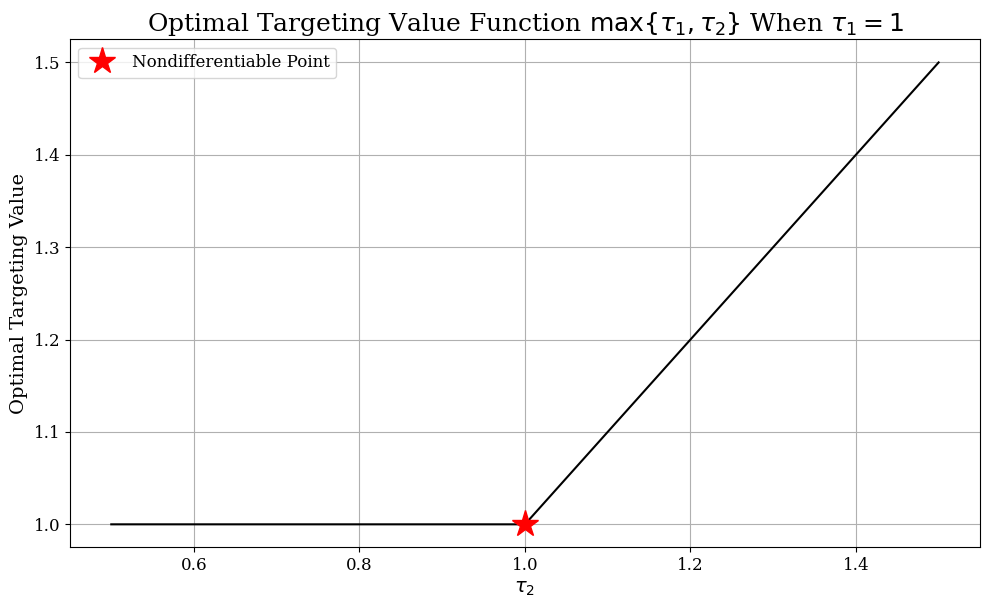

In [8]:
tau1 = 1
tau2_arr = np.linspace(0.5, 1.5, 1000)

val_arr = np.array([ts.optimize(te_arr=np.array([tau1, tau2]))[1] for tau2 in tau2_arr])

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.plot(tau2_arr, val_arr, color='black')


# mark discontinuous point
ax.plot(tau1, tau1, 'r*', markersize=20, label='Nondifferentiable Point')

# plot attributes
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_title(r'Optimal Targeting Value Function $\max\{\tau_1, \tau_2\}$ When $\tau_1 = 1$', fontsize=title_size)
ax.set_xlabel(r'$\tau_2$', fontsize=axis_label_size)
ax.set_ylabel('Optimal Targeting Value', fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()


# Winner's Curse

In [87]:
operations_params = {}

# dgp_params = {'te_arr': np.array([0.1, 0.15, 0.2, 0.25, 0.3]), 'noise_std': 5}
dgp_params = {'te_arr': np.array([0.1, 0.11]), 'noise_std': 1}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

# empirical distribution of winner's curse
estimators_dict = {}

result_records = ts.repeated_experiments(
    operations_params=operations_params,
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=False, 
)

wc_measures_dict = ts.calculate_winners_curse_measures(
    result_records=result_records, 
    estimators_dict=estimators_dict, data_params=data_params
)

print(f"Average Estimated Targeting Value: {wc_measures_dict['nc_val_est_avg']:.4f} ({wc_measures_dict['nc_val_est_se']:.4f})")
print(f"Average True Targeting Value: {wc_measures_dict['nc_val_true_avg']:.4f} ({wc_measures_dict['nc_val_true_se']:.4f})")
print(f"Average Winner's Curse: {wc_measures_dict['nc_wc_avg']:.4f} ({wc_measures_dict['nc_wc_se']:.4f})")
print(f"Average Winner's Curse Percentage of True Value: {100 * wc_measures_dict['nc_wc_pct_avg']:.2f}% ({100 * wc_measures_dict['nc_wc_pct_se']:.2f}%)")

print(f"\nRMSE={wc_measures_dict['nc_wc_rmse']:.4f}")

Average Estimated Targeting Value: 0.1855 (0.0116)
Average True Targeting Value: 0.1051 (0.0005)
Average Winner's Curse: 0.0805 (0.0116)
Average Winner's Curse Percentage of True Value: 76.93% (11.11%)

RMSE=0.1414


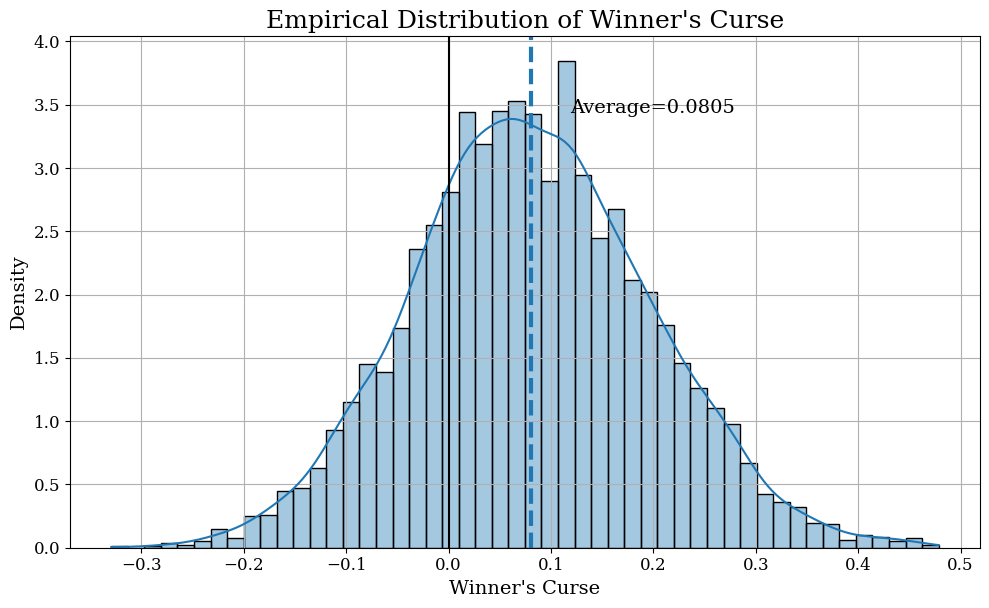

In [98]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', alpha=0.4)
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--', linewidth=3)
ax.axvline(0, color='black', linestyle='-', linewidth=1.5)
ax.annotate(
    f"Average={wc_measures_dict['nc_wc_avg']:.4f}", 
    xy=(0.55, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Estimating Winner's Curse

In [11]:
dgp = SingleSegment(**dgp_params)
treatment_arr, outcome_arr = dgp.sample(**data_params, seed=0)

## Standard Bootstrap

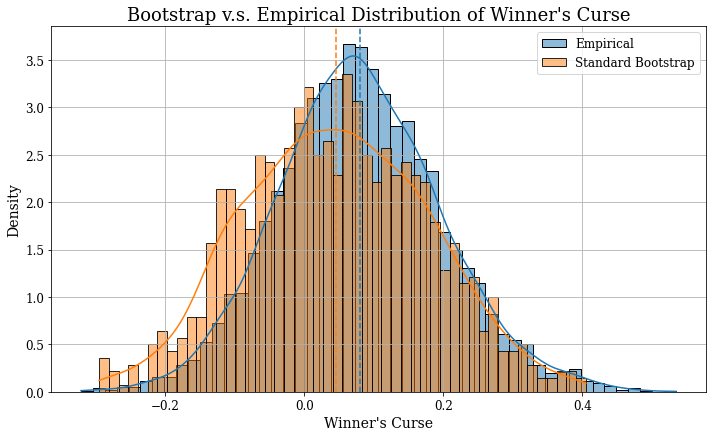

In [12]:
# generate bootstrap distribution
boot_wc_dstn_arr = ts.get_wc_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    **operations_params, n_bootstraps=1000
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n bootstrap

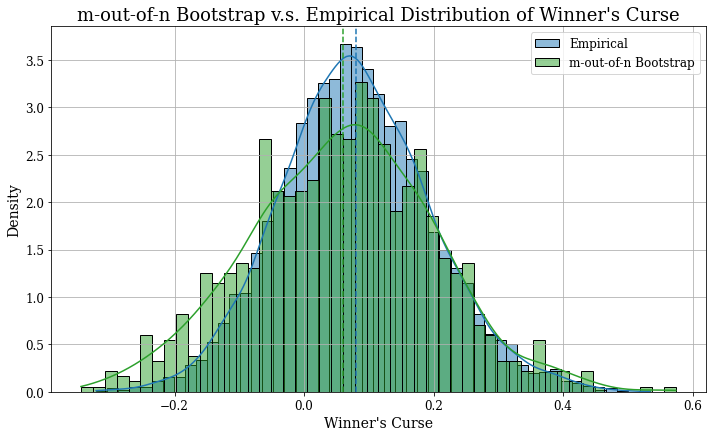

In [13]:
# generate bootstrap distribution
boot_wc_dstn_arr = ts.get_wc_m_out_of_n_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    **operations_params, power=0.95, n_bootstraps=1000, conditional_on_treated=True, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title("m-out-of-n Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

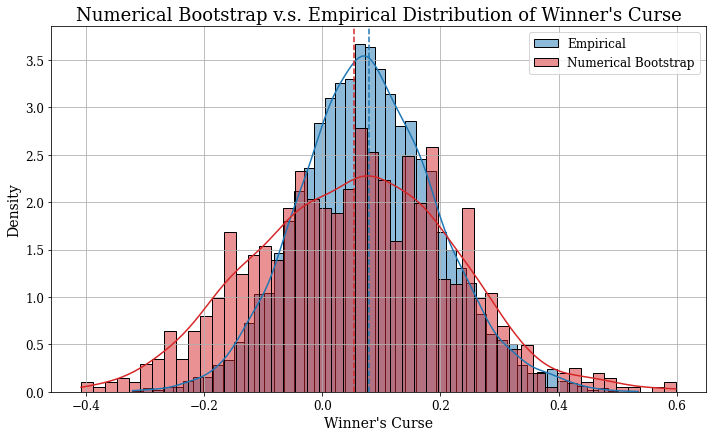

In [14]:
# generate bootstrap distribution
boot_wc_dstn_arr = ts.get_wc_num_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    **operations_params, power=-0.45, n_bootstraps=1000, conditional_on_treated=True, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title("Numerical Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [138]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, 0.11]), 'noise_std': 1, 'response_type': 'continuous'}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

estimators_dict = {
    'sample_splitting': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {}, 
        'display_name': 'Sample Splitting'
    }, 
    'empirical_bayes': {
        'estimator': ts.empirical_bayes_estimate, 
        'params': {'n_degree': 5, 'n_knots': 2, 'bin_width': 0.1, 'smoothing': 0.5}, 
        'display_name': 'Empirical Bayes'
    }, 
    'normal_prior_bayes': {
        'estimator': ts.normal_prior_bayes_estimate, 
        'params': {'prior_mean': 0, 'prior_std': 1}, 
        'display_name': 'Normal Prior Bayes'
    }, 
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.93,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.43,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}

In [139]:
result_records = ts.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = ts.calculate_winners_curse_measures(
    result_records=result_records,
    estimators_dict=estimators_dict, data_params=data_params
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   14.4s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:   18.7s
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:   23.6s
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:   29.3s
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:   35.6s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:   36.0s finished


In [140]:
wc_dict = {}
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_dict.update({
        display_name: {
            "Avg. Winner's Curse": wc_measures_dict[f'{estimator}_wc_avg'], "S.E. Winner's Curse": wc_measures_dict[f'{estimator}_wc_se'],
            'Correct Decision Rate': str(100 * wc_measures_dict[f'{estimator}_correct_decision_rate']) + '%'
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 
print("Overestimated Profit Lift: ")
wc_df.round(4)

Overestimated Profit Lift: 


,Avg. Winner's Curse,S.E. Winner's Curse,Correct Decision Rate
No Correction,0.0805,0.0116,50.839999999999996%
Sample Splitting,0.0004,0.0200,52.12%
Empirical Bayes,0.0608,0.0167,50.839999999999996%
Normal Prior Bayes,0.0768,0.0114,50.839999999999996%
Standard Bootstrap,0.0251,0.0129,50.839999999999996%
m-out-of-n Bootstrap,0.0099,0.0130,50.839999999999996%
Numerical Bootstrap,0.0042,0.0135,50.839999999999996%


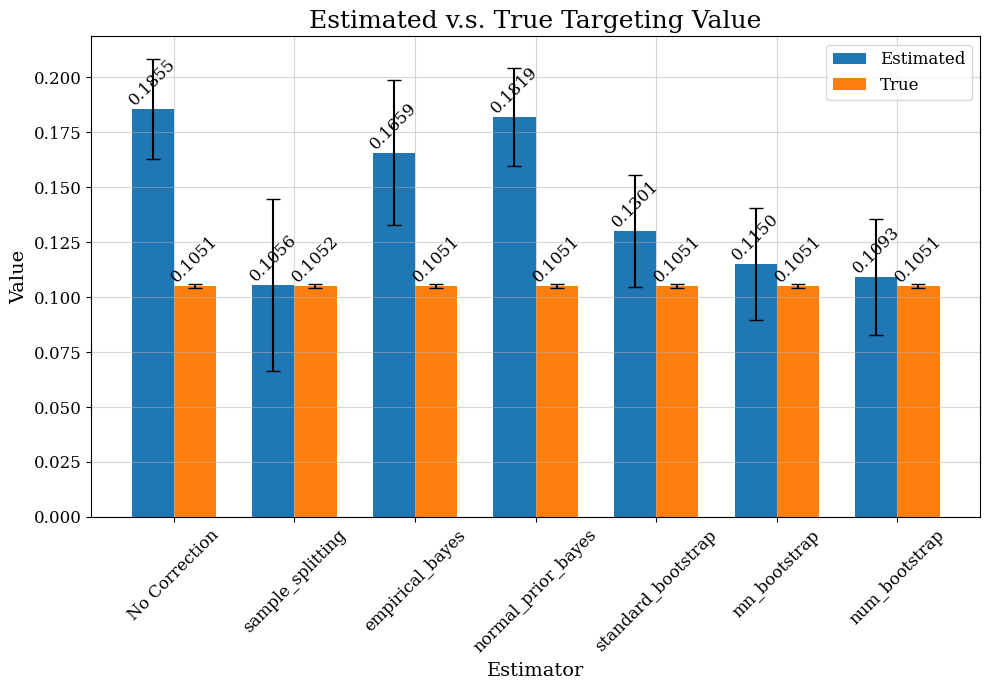

In [141]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

x = np.arange(len(estimators_dict) + 1)
width = 0.35

ax.bar(
    x - width/2, 
    height=[wc_measures_dict[f'{estimator}_val_est_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    yerr=[1.96 * wc_measures_dict[f'{estimator}_val_est_se'] for estimator in ['nc'] + list(estimators_dict.keys())],
    capsize=5, 
    width=width, label='Estimated', color='C0'
)

ax.bar(
    x + width/2, 
    height=[wc_measures_dict[f'{estimator}_val_true_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    yerr=[1.96 * wc_measures_dict[f'{estimator}_val_true_se'] for estimator in ['nc'] + list(estimators_dict.keys())],
    capsize=5, 
    width=width, label='True', color='C1'
)

# add text annotation
for i, (val_est, val_true) in enumerate(zip(
    [wc_measures_dict[f'{estimator}_val_est_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    [wc_measures_dict[f'{estimator}_val_true_avg'] for estimator in ['nc'] + list(estimators_dict.keys())]
)):
    ax.text(
        i - width/2, val_est, f"{val_est:.4f}", 
        ha='center', va='bottom', fontsize=tick_label_size, rotation=45
    )
    ax.text(
        i + width/2, val_true, f"{val_true:.4f}", 
        ha='center', va='bottom', fontsize=tick_label_size, rotation=45
    )

ax.set_title("Estimated v.s. True Targeting Value", fontsize=title_size)
ax.set_xlabel("Estimator", fontsize=axis_label_size)
ax.set_ylabel("Value", fontsize=axis_label_size)
ax.set_xticks(x)
ax.set_xticklabels(['No Correction'] + list(estimators_dict.keys()), rotation=45)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

ax.legend(['Estimated', 'True'], fontsize=legend_label_size)
ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()

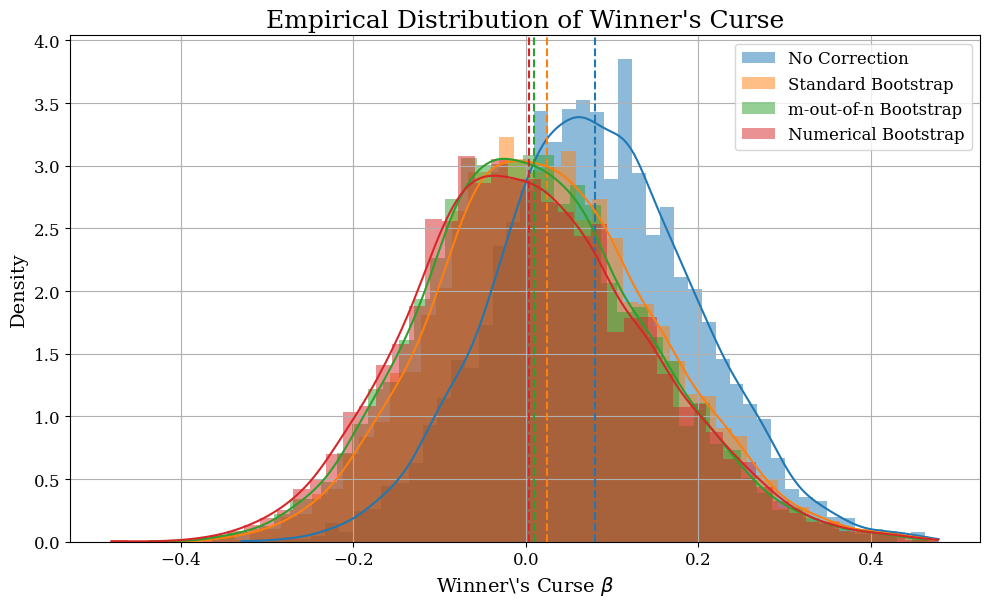

In [143]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# winner's curse MPE
for idx, estimator in enumerate(['nc', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'
    sns.histplot(
        wc_measures_dict[f'{estimator}_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color=f'C{idx}', edgecolor=None, 
        label=display_name
    )
    ax.axvline(wc_measures_dict[f'{estimator}_wc_avg'], color=f'C{idx}', linestyle='--')


# ax.annotate(
#     f"Mean={wc_measures_dict['nc_wc_avg']:.4f}", 
#     xy=(0.55, 0.85), xycoords='axes fraction', fontsize=axis_label_size
# )

ax.set_title('Empirical Distribution of Winner\'s Curse', fontsize=title_size)
ax.set_xlabel(r'Winner\'s Curse $\beta$', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-bias-correction.png')
plt.show()

# Sensitivity Analysis

## Hyperparameter w.r.t. $\tau$

### m-out-of-n bootstrap

In [13]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, np.nan]), 'noise_std': 1}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': np.nan,
        }
    }, 
}

In [ ]:
tau2_list = [-0.1, -0.05, 0, 0.05, 0.075, 0.1, 0.125, 0.15, 0.2]
power_list = [0.88, 0.90, 0.92, 0.95, 0.97]
result_dict = {(tau2, power): None for tau2 in tau2_list for power in power_list}

for tau2 in tau2_list:
    dgp_params['te_arr'][1] = tau2
    for power in power_list: 
        print(f'Tau2 = {tau2}, Power = {power}')
        estimators_dict['mn_bootstrap']['params']['power'] = power
        
        result_record = ts.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True, n_jobs=-1
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })

        result_dict[(tau2, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(tau2, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/ts_mnb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [51]:
with open('results/ts_mnb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'standard_bootstrap_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'mn_bootstrap_mean']]
    best_wc_list[idx] = temp['mn_bootstrap_mean'].loc[(-temp['mn_bootstrap_mean'].abs()).idxmax()]

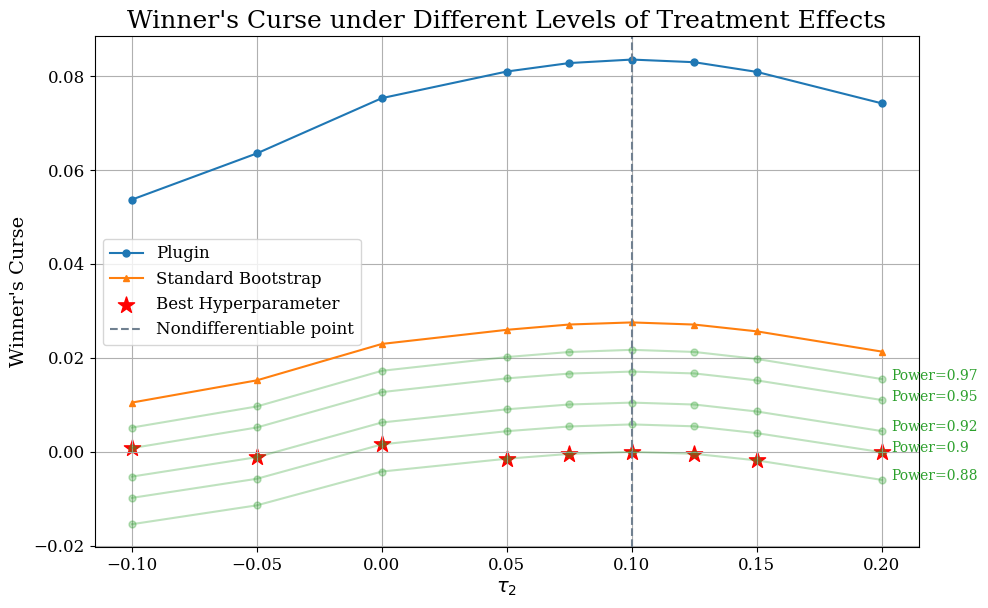

In [53]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['standard_bootstrap_mean'], '^-', markersize=5, label='Standard Bootstrap', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'mn_bootstrap_mean']]
    ax.plot(mnb_df['tau'], mnb_df['mn_bootstrap_mean'], 'o-', color='C2', alpha=0.3, markersize=5)
    ax.text(
        mnb_df['tau'].values[-1] * 1.02, mnb_df['mn_bootstrap_mean'].values[-1] * 0.99, 
        f'Power={power}', 
        fontsize=10, color='C2'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best Hyperparameter')

# plot the nondifferentiable point
ax.axvline(dgp_params['te_arr'][0], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects", fontsize=title_size)
ax.set_xlabel(r'$\tau_2$', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/ts-mnb-hyperparam-test.png')
plt.show()

### Numerical bootstrap

In [31]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, np.nan]), 'noise_std': 1}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': np.nan, 
        }
    }
}

In [ ]:
tau2_list = [-0.1, -0.05, 0, 0.05, 0.075, 0.1, 0.125, 0.15, 0.2]
power_list = [-0.40, -0.41, -0.42, -0.43, -0.44, -0.45, -0.46, -0.47, -0.48, -0.49]
result_dict = {(tau2, power): None for tau2 in tau2_list for power in power_list}

for tau2 in tau2_list:
    dgp_params['te_arr'][1] = tau2
    for power in power_list: 
        print(f'Tau2 = {tau2}, Power = {power}')
        estimators_dict['num_bootstrap']['params']['power'] = power
        
        result_record = ts.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True, n_jobs=-1
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })

        result_dict[(tau2, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(tau2, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/ts_numb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [54]:
with open('results/ts_numb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

result_df = result_df[result_df['power'].isin([-0.40, -0.42, -0.44, -0.46, -0.48])]

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'standard_bootstrap_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'num_bootstrap_mean']]
    best_wc_list[idx] = temp['num_bootstrap_mean'].loc[(-temp['num_bootstrap_mean'].abs()).idxmax()]

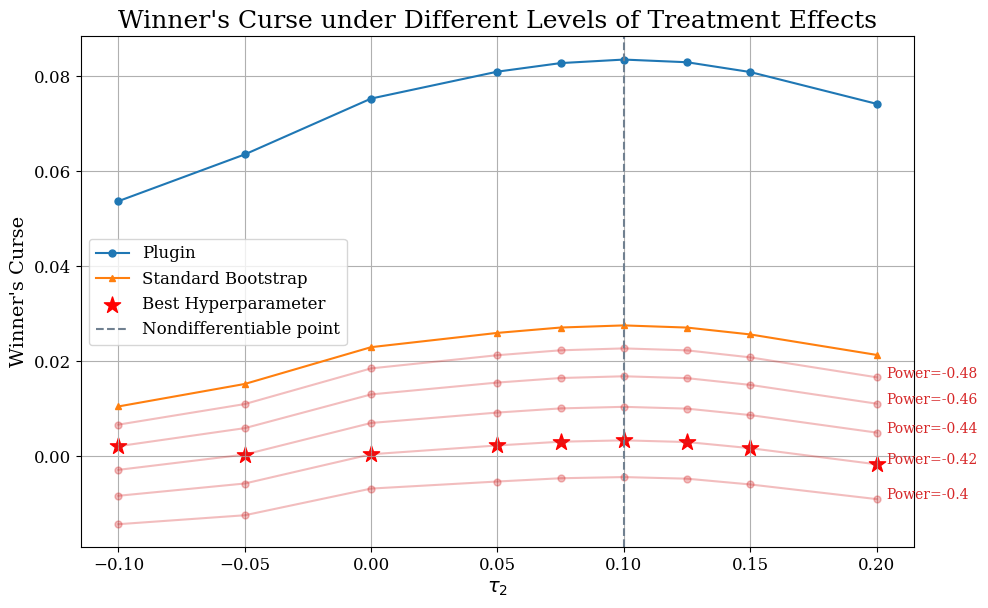

In [55]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['standard_bootstrap_mean'], '^-', markersize=5, label='Standard Bootstrap', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'num_bootstrap_mean']]
    ax.plot(mnb_df['tau'], mnb_df['num_bootstrap_mean'], 'o-', color='C3', alpha=0.3, markersize=5)
    ax.text(
        mnb_df['tau'].values[-1] * 1.02, mnb_df['num_bootstrap_mean'].values[-1] * 0.99, 
        f'Power={power}', 
        fontsize=10, color='C3'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best Hyperparameter')

# plot the nondifferentiable point
ax.axvline(dgp_params['te_arr'][0], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects", fontsize=title_size)
ax.set_xlabel(r'$\tau_2$', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/ts-numb-hyperparam-test.png')
plt.show()

## Diff in treatment effects

In [56]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, np.nan]), 'noise_std': 1}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': np.nan,
        }
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': np.nan,
        }
    }
}

In [61]:
params_records = [
    {'te_diff': 0, 'mn_power': 0.88, 'num_power': -0.42},
    {'te_diff': 0.01, 'mn_power': 0.88, 'num_power': -0.42},
    {'te_diff': 0.05, 'mn_power': 0.88, 'num_power': -0.42},
    {'te_diff': 0.1, 'mn_power': 0.88, 'num_power': -0.42},
    {'te_diff': 0.15, 'mn_power': 0.88, 'num_power': -0.42},
    {'te_diff': 0.2, 'mn_power': 0.88, 'num_power': -0.42},
    # {'te_diff': 0.3, 'mn_power': 0.92, 'num_power': -0.42},
    # {'te_diff': 0.4, 'mn_power': 0.95, 'num_power': -0.45},
    # {'te_diff': 0.5, 'mn_power': 0.95, 'num_power': -0.45},
]

result_dict = ts.te_diff_test(
    params_records=params_records, 
    operations_params=operations_params,
    dgp_params=dgp_params,
    data_params=data_params,
    experiment_params=experiment_params,
    estimators_dict=estimators_dict,
    n_jobs=-1, verbose=True, 
    save_path='results/ts_tediff_test.pkl'
)


Running with treatment effects = (0.1000, 0.1000)...
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   16.7s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   29.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   38.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Finished te diff 0 in 0:00:38.136548
Running with treatment effects = (0.1000, 0.1100)...
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   14.0s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   26.6s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   35.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Finished te diff 0.01 in 0:00:35.625205
Running with treatment effects = (0.1000, 0.1500)...
Running 1000 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   14.2s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   26.8s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   35.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Finished te diff 0.15 in 0:00:35.975039
Running with treatment effects = (0.1000, 0.3000)...
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   14.3s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   26.7s


Finished te diff 0.2 in 0:00:35.894174


[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   35.8s finished


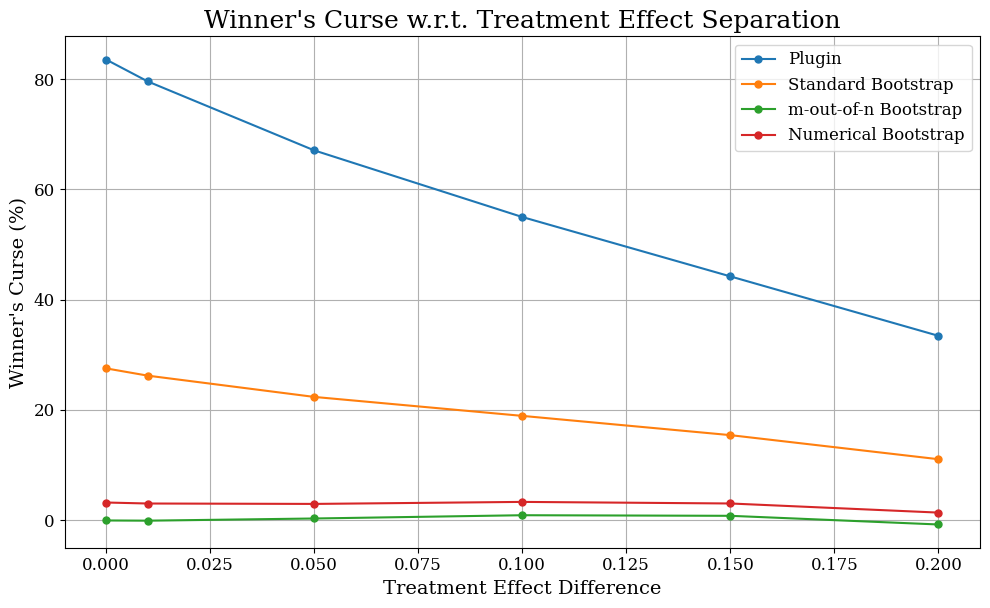

In [62]:
with open('results/ts_tediff_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T

# result_df.index = 100 *  result_df.index / 0.1

ts.visualize_sensitivity_test(
    estimators_list=['plugin', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap'], 
    result_df=result_df, metric='wc_pct', 
    plot_error_bar=False, 
    title='Winner\'s Curse w.r.t. Treatment Effect Separation',
    model_label_map=model_label_map, 
    label='Treatment Effect Difference',
    save_path=None
)

## Noise level

In [5]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, 0.11]), 'noise_std': np.nan}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.88,
        }
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': -0.42,
        }
    }
}

In [ ]:
noise_level_list = [0.1, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5]

result_dict = ts.noise_level_test(
    noise_levels=noise_level_list, 
    operations_params=operations_params,
    dgp_params=dgp_params,
    data_params=data_params,
    experiment_params=experiment_params,
    estimators_dict=estimators_dict,
    n_jobs=-1, verbose=True, 
    save_path='results/ts_noise_level_test.pkl'
)

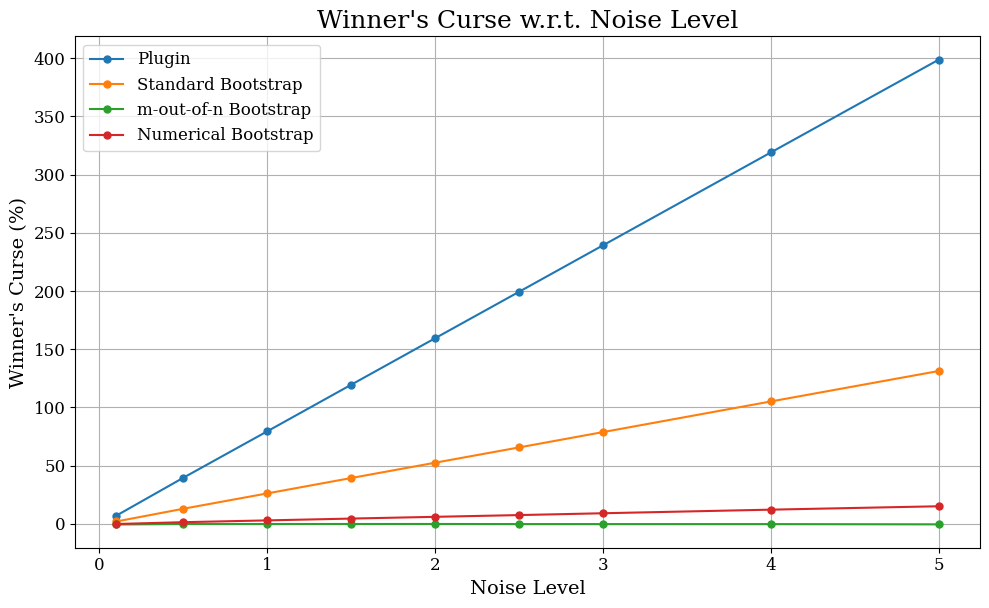

In [15]:
with open('results/ts_noise_level_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T

ts.visualize_sensitivity_test(
    estimators_list=['plugin', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap'], 
    result_df=result_df, metric='wc_pct', 
    plot_error_bar=False, 
    title='Winner\'s Curse w.r.t. Noise Level',
    model_label_map=model_label_map, 
    label='Noise Level',
    save_path=None
)

## Ratio test: te_diff / noise_std


In [99]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, np.nan]), 'noise_std': np.nan}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.88,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': -0.42,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}

In [100]:
ratio_arr = np.array([0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
noise_std = 1
te_diff = noise_std * ratio_arr

result_dict = {(te_diff, noise_std): None for te_diff in te_diff}

for te_diff in tqdm(te_diff):
    dgp_params['te_arr'][1] = dgp_params['te_arr'][0] + te_diff
    dgp_params['noise_std'] = noise_std
    result_dict[(te_diff, noise_std)] = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=False, n_jobs=-1
    )

for key in result_dict.keys():
    result_dict[key] = ts.calculate_winners_curse_measures(
        result_records=result_dict[key],
        estimators_dict=estimators_dict, data_params=data_params
    )

100%|██████████| 14/14 [01:33<00:00,  6.68s/it]


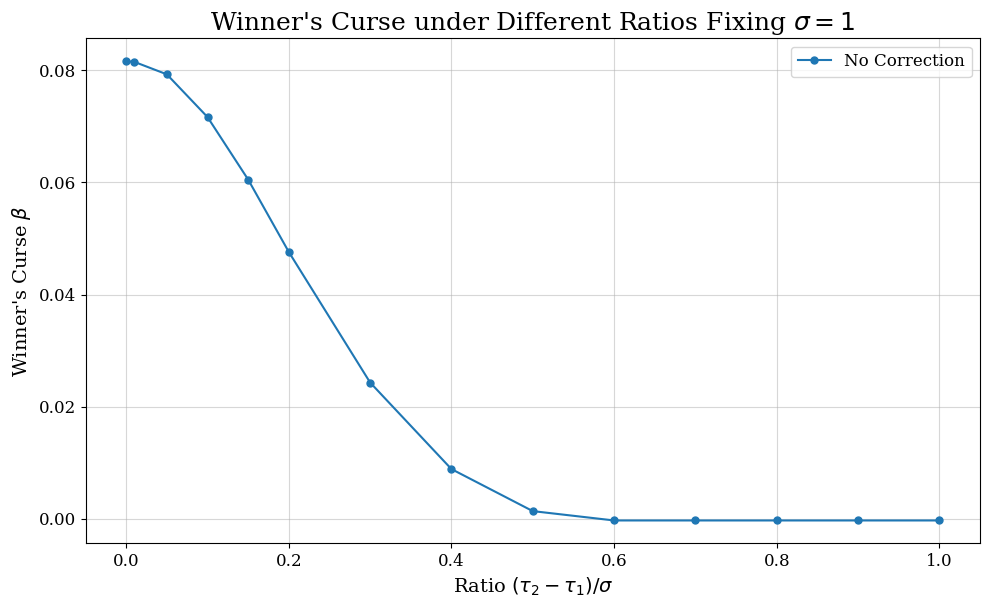

In [103]:
wc_avg_arr = np.array([result_dict[key]['nc_wc_avg'] for key in result_dict.keys()])
wc_se_arr = np.array([result_dict[key]['nc_wc_se'] for key in result_dict.keys()])

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plot winner's curse of no correction 
for idx, estimator in enumerate(['nc']):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'
    wc_avg_arr = np.array([result_dict[key][f'{estimator}_wc_avg'] for key in result_dict.keys()])
    wc_se_arr = np.array([result_dict[key][f'{estimator}_wc_se'] for key in result_dict.keys()])
    ax.plot(ratio_arr, wc_avg_arr, 'o-', markersize=5, label=display_name, color=f'C{idx}')
    # ax.fill_between(ratio_arr, wc_avg_arr - 1.96 * wc_se_arr, wc_avg_arr + 1.96 * wc_se_arr, color=f'C{idx}', alpha=0.3)

ax.set_title(r"Winner's Curse under Different Ratios Fixing $\sigma={}$".format(noise_std), fontsize=title_size)
ax.set_xlabel(r'Ratio $(\tau_2 - \tau_1) / \sigma$', fontsize=axis_label_size)
ax.set_ylabel(r"Winner's Curse $\beta$", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

In [71]:
ratio = 0.1
noise_std_arr = np.array([0.1, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5])
te_diff_arr = noise_std_arr * ratio

result_dict = {(te_diff, noise_std): None for te_diff, noise_std in zip(te_diff_arr, noise_std_arr)}

for te_diff, noise_std in tqdm(zip(te_diff_arr, noise_std_arr)):
    dgp_params['te_arr'][1] = dgp_params['te_arr'][0] + te_diff
    dgp_params['noise_std'] = noise_std
    result_dict[(te_diff, noise_std)] = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=False, n_jobs=-1
    )

for key in result_dict.keys():
    result_dict[key] = ts.calculate_winners_curse_measures(
        result_records=result_dict[key],
        estimators_dict=estimators_dict, data_params=data_params
    )

9it [00:57,  6.35s/it]


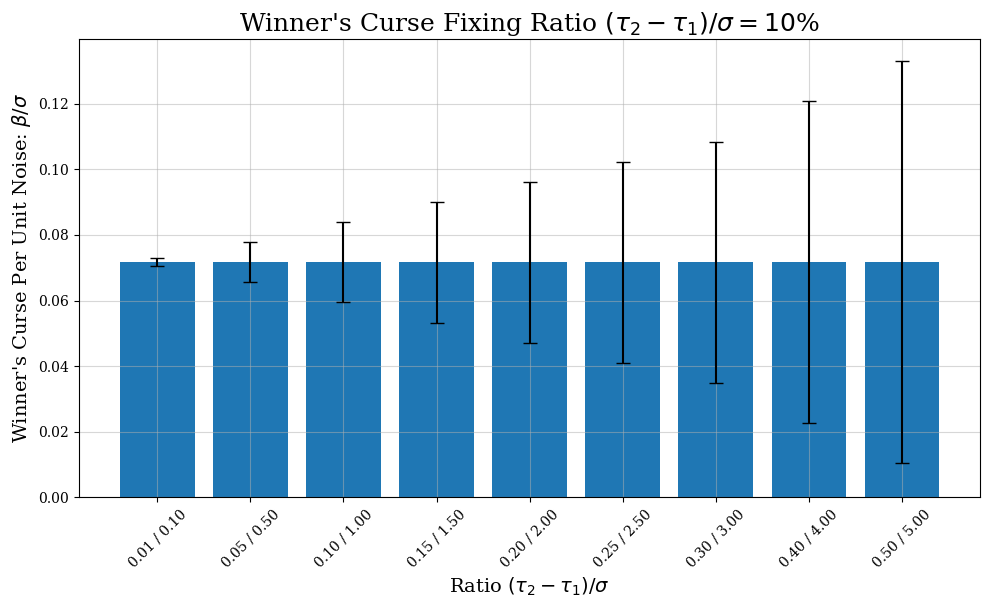

In [79]:
wc_avg_arr = np.array([result_dict[key]['nc_wc_avg'] for key in result_dict.keys()]) / noise_std_arr
wc_se_arr = np.array([result_dict[key]['nc_wc_se'] for key in result_dict.keys()])

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plot winner's curse of no correction for each te_diff / noise_std pair
ax.bar(
    np.arange(len(wc_avg_arr)), wc_avg_arr, yerr=wc_se_arr, capsize=5, color='C0'
)

ax.set_title(r"Winner's Curse Fixing Ratio $(\tau_2 - \tau_1) / \sigma = {:.0f}$%".format(100 * ratio), fontsize=title_size)
ax.set_xlabel(r'Ratio $(\tau_2 - \tau_1) / \sigma$', fontsize=axis_label_size)
ax.set_ylabel(r"Winner's Curse Per Unit Noise: $\beta / \sigma$", fontsize=axis_label_size)
ax.set_xticks(np.arange(len(wc_avg_arr)))
ax.set_xticklabels([f'{te_diff:.2f} / {noise_std:.2f}' for te_diff, noise_std in zip(te_diff_arr, noise_std_arr)], rotation=45)
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

## Sample size

In [ ]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, 0.2]), 'noise_std': 1}

data_params = {'sample_size': np.nan}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.97,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': -0.47,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}

In [102]:
sample_sizes = np.array([20, 50, 100, 200, 500, 1000])

result_dict = {sample_size: None for sample_size in sample_sizes}

for sample_size in tqdm(sample_sizes):
    data_params['sample_size'] = int(sample_size)
    result_dict[sample_size] = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=False, n_jobs=-1
    )

for key in result_dict.keys():
    result_dict[key] = ts.calculate_winners_curse_measures(
        result_records=result_dict[key],
        estimators_dict=estimators_dict, data_params=data_params
    )

100%|██████████| 6/6 [00:50<00:00,  8.43s/it]


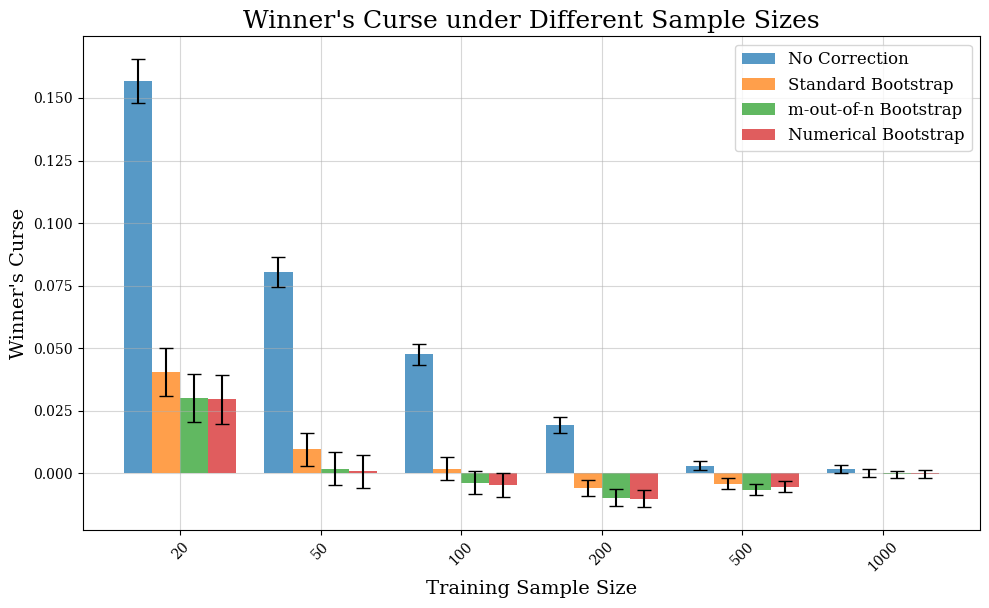

In [103]:
wc_avg_arr = np.array([result_dict[key]['nc_wc_avg'] for key in result_dict.keys()])
wc_se_arr = np.array([result_dict[key]['nc_wc_se'] for key in result_dict.keys()])

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

width = 0.2

# plot winner's curse of no correction for each te_diff / noise_std pair
for idx, estimator in enumerate(['nc', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):

    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'
    wc_avg_arr = np.array([result_dict[key][f'{estimator}_wc_avg'] for key in result_dict.keys()])
    wc_se_arr = np.array([result_dict[key][f'{estimator}_wc_se'] for key in result_dict.keys()])
    ax.bar(
        np.arange(len(wc_avg_arr)) + (idx - 1.5) * width, wc_avg_arr, yerr=wc_se_arr, capsize=5, color=f'C{idx}', alpha=0.75, width=width
    )

ax.set_title("Winner's Curse under Different Sample Sizes", fontsize=title_size)
ax.set_xlabel('Training Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.set_xticks(np.arange(len(wc_avg_arr)))
ax.set_xticklabels(sample_sizes, rotation=45)
ax.grid(True, alpha=0.5)
ax.legend(['No Correction'] + [estimators_dict[estimator]['display_name'] for estimator in ['standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']], fontsize=legend_label_size)

plt.tight_layout()
plt.show()

# Binary Response

In [119]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, 0.11]), 'response_type': 'binary'}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

estimators_dict = {
    'sample_splitting': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {}, 
        'display_name': 'Sample Splitting'
    }, 
    # 'empirical_bayes': {
    #     'estimator': ts.empirical_bayes_estimate, 
    #     'params': {'n_degree': 5, 'n_knots': 2, 'bin_width': 0.1, 'smoothing': 0.5}, 
    #     'display_name': 'Empirical Bayes'
    # }, 
    'normal_prior_bayes': {
        'estimator': ts.normal_prior_bayes_estimate, 
        'params': {'prior_mean': 0, 'prior_std': 1}, 
        'display_name': 'Normal Prior Bayes'
    }, 
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}

In [120]:
result_records = ts.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = ts.calculate_winners_curse_measures(
    result_records=result_records,
    estimators_dict=estimators_dict, data_params=data_params
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 708 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 1408 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 2308 tasks      | elapsed:   15.2s
[Parallel(n_jobs=-1)]: Done 3408 tasks      | elapsed:   22.4s
[Parallel(n_jobs=-1)]: Done 4708 tasks      | elapsed:   30.9s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:   32.7s finished


In [121]:
wc_dict = {}
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_dict.update({
        display_name: {
            "Avg. Winner's Curse": wc_measures_dict[f'{estimator}_wc_avg'], "S.E. Winner's Curse": wc_measures_dict[f'{estimator}_wc_se'],
            # 'wc_pct_avg': wc_measures_dict[f'{estimator}_wc_pct_avg'], 'wc_pct_se': wc_measures_dict[f'{estimator}_wc_pct_se'],
            # 'wc_rmse': wc_measures_dict[f'{estimator}_wc_rmse']
            "Correct Decision Rate": wc_measures_dict[f'{estimator}_correct_decision_rate']
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index') * 100
del wc_dict 

print("Overestimated Purchase Probability Lift: ")
wc_df.round(4).apply(lambda x: x.astype(str) + '%')

Overestimated Purchase Probability Lift: 


,Avg. Winner's Curse,S.E. Winner's Curse,Correct Decision Rate
No Correction,2.3696%,0.3839%,56.02%
Sample Splitting,-0.161%,0.6109%,53.28%
Normal Prior Bayes,2.3384%,0.3822%,56.02%
Standard Bootstrap,0.6973%,0.4023%,56.02%
m-out-of-n Bootstrap,0.3811%,0.3997%,56.02%
Numerical Bootstrap,0.2629%,0.409%,56.02%


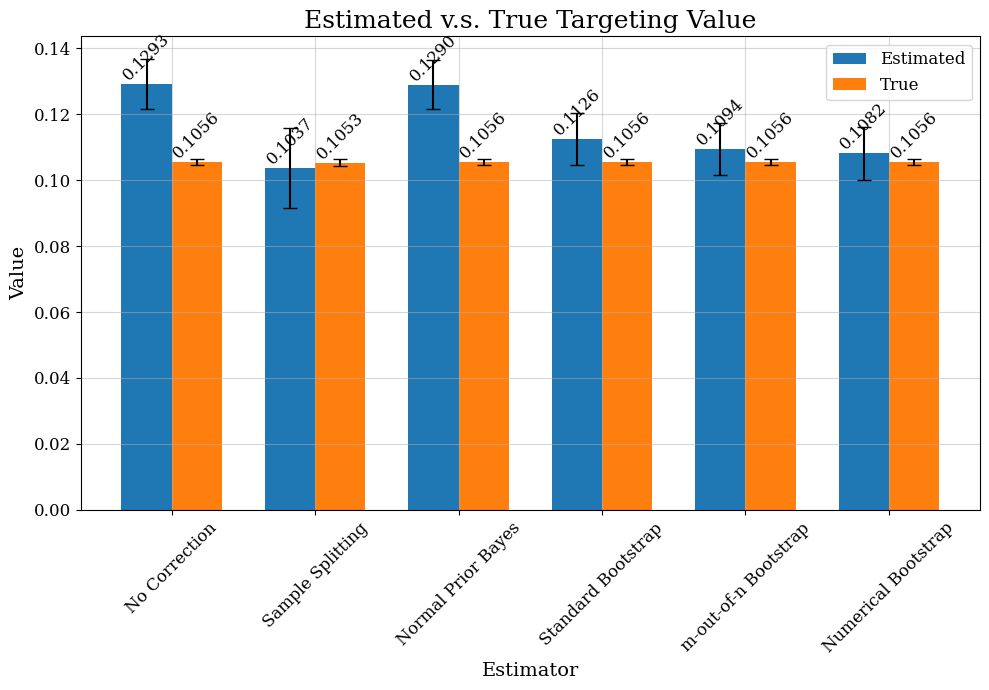

In [122]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

x = np.arange(len(estimators_dict) + 1)
width = 0.35

ax.bar(
    x - width/2, 
    height=[wc_measures_dict[f'{estimator}_val_est_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    yerr=[1.96 * wc_measures_dict[f'{estimator}_val_est_se'] for estimator in ['nc'] + list(estimators_dict.keys())],
    capsize=5, 
    width=width, label='Estimated', color='C0'
)

ax.bar(
    x + width/2, 
    height=[wc_measures_dict[f'{estimator}_val_true_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    yerr=[1.96 * wc_measures_dict[f'{estimator}_val_true_se'] for estimator in ['nc'] + list(estimators_dict.keys())],
    capsize=5, 
    width=width, label='True', color='C1'
)

# add text annotation
for i, (val_est, val_true) in enumerate(zip(
    [wc_measures_dict[f'{estimator}_val_est_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    [wc_measures_dict[f'{estimator}_val_true_avg'] for estimator in ['nc'] + list(estimators_dict.keys())]
)):
    ax.text(
        i - width/2, val_est, f"{val_est:.4f}", 
        ha='center', va='bottom', fontsize=tick_label_size, rotation=45
    )
    ax.text(
        i + width/2, val_true, f"{val_true:.4f}", 
        ha='center', va='bottom', fontsize=tick_label_size, rotation=45
    )

ax.set_title("Estimated v.s. True Targeting Value", fontsize=title_size)
ax.set_xlabel("Estimator", fontsize=axis_label_size)
ax.set_ylabel("Value", fontsize=axis_label_size)
ax.set_xticks(x)
ax.set_xticklabels(['No Correction'] + [estimator['display_name'] for estimator in estimators_dict.values()], rotation=45)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

ax.legend(['Estimated', 'True'], fontsize=legend_label_size)
ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()

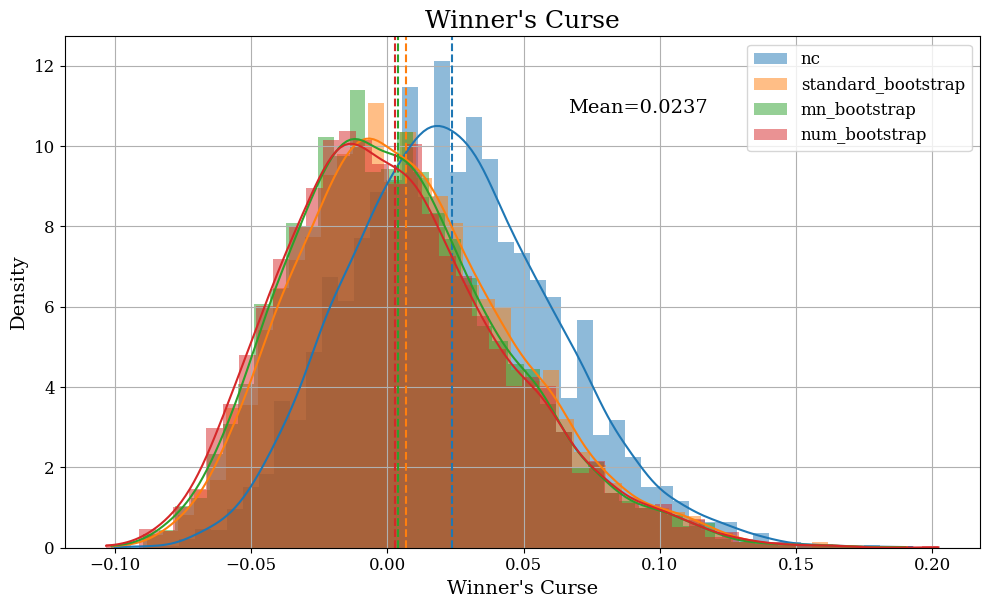

In [123]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# winner's curse MPE
for idx, estimator in enumerate(['nc', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):
    sns.histplot(
        wc_measures_dict[f'{estimator}_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color=f'C{idx}', edgecolor=None, 
        label=estimator
    )
    ax.axvline(wc_measures_dict[f'{estimator}_wc_avg'], color=f'C{idx}', linestyle='--')


ax.annotate(
    f"Mean={wc_measures_dict['nc_wc_avg']:.4f}", 
    xy=(0.55, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)

ax.set_title('Winner\'s Curse', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-bias-correction.png')
plt.show()

## Sample Size

In [25]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, 0.11]), 'response_type': 'binary'}

data_params = {'sample_size': np.nan}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.92,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.43,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}

In [26]:
sample_sizes = np.array([50, 100, 200, 300, 400, 500, 1000])

result_dict = {sample_size: None for sample_size in sample_sizes}

for sample_size in tqdm(sample_sizes):
    data_params['sample_size'] = int(sample_size)
    result_dict[sample_size] = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=False, n_jobs=-1
    )

for key in result_dict.keys():
    result_dict[key] = ts.calculate_winners_curse_measures(
        result_records=result_dict[key],
        estimators_dict=estimators_dict, data_params=data_params
    )

100%|██████████| 7/7 [01:00<00:00,  8.71s/it]


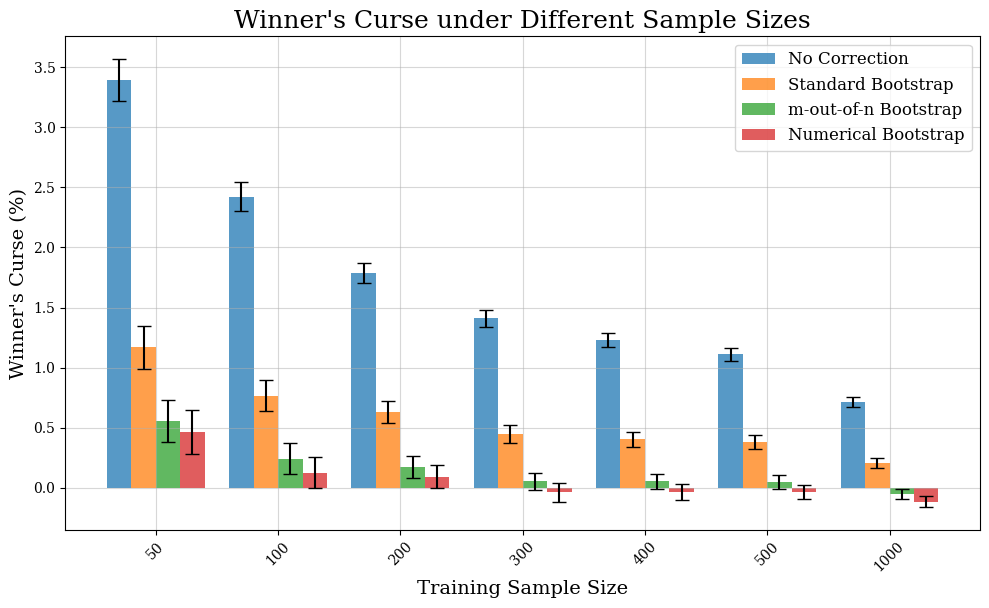

In [27]:
wc_avg_arr = np.array([result_dict[key]['nc_wc_avg'] for key in result_dict.keys()])
wc_se_arr = np.array([result_dict[key]['nc_wc_se'] for key in result_dict.keys()])

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

width = 0.2

# plot winner's curse of no correction for each te_diff / noise_std pair
for idx, estimator in enumerate(['nc', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):

    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'
    wc_avg_arr = 100 * np.array([result_dict[key][f'{estimator}_wc_avg'] for key in result_dict.keys()])
    wc_se_arr = 100 * np.array([result_dict[key][f'{estimator}_wc_se'] for key in result_dict.keys()])
    ax.bar(
        np.arange(len(wc_avg_arr)) + (idx - 1.5) * width, wc_avg_arr, yerr=wc_se_arr, capsize=5, color=f'C{idx}', alpha=0.75, width=width
    )

ax.set_title("Winner's Curse under Different Sample Sizes", fontsize=title_size)
ax.set_xlabel('Training Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_xticks(np.arange(len(wc_avg_arr)))
ax.set_xticklabels(sample_sizes, rotation=45)
ax.grid(True, alpha=0.5)
ax.legend(['No Correction'] + [estimators_dict[estimator]['display_name'] for estimator in ['standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']], fontsize=legend_label_size)

plt.tight_layout()
plt.show()

## Diff in Effects

In [17]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, np.nan]), 'response_type': 'binary'}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.93,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}